In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams["font.size"] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

In [2]:
def plotBackProjection(filePath, num_points, title=None):
    file = uproot.open(f"{filePath}")
    projection = file["BackProjection/h_bp_all"]
    countsArray, binsArrayX, binsArrayY = projection.to_numpy()
    
    threshold = 0.5 / num_points
    H_masked = np.ma.masked_less(countsArray.T, threshold)

    fig, ax = plt.subplots(1,1,figsize=(6,5))
    cmap = plt.cm.viridis.copy()
    cmap.set_bad("white")
    pcm = ax.pcolormesh(binsArrayX, binsArrayY, H_masked, cmap=cmap, vmin=0)
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label("Counts")
    ax.set_xlim(binsArrayX[0], binsArrayX[-1])
    ax.set_ylim(binsArrayY[0], binsArrayY[-1])
    ax.set_xlabel("Y (cm)")
    ax.set_ylabel("Z (cm)")
    ax.set_aspect("equal")
    if title != None:
        ax.set_title(title)

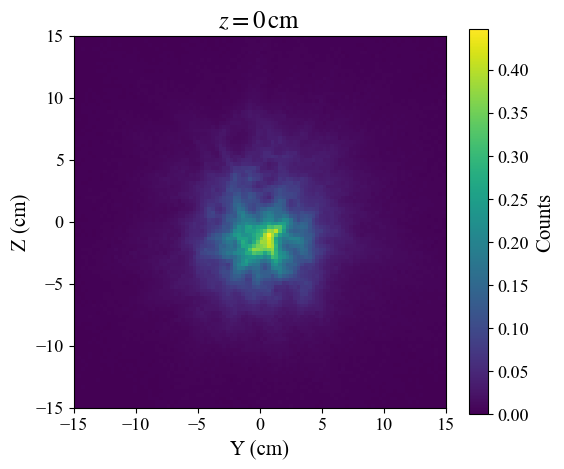

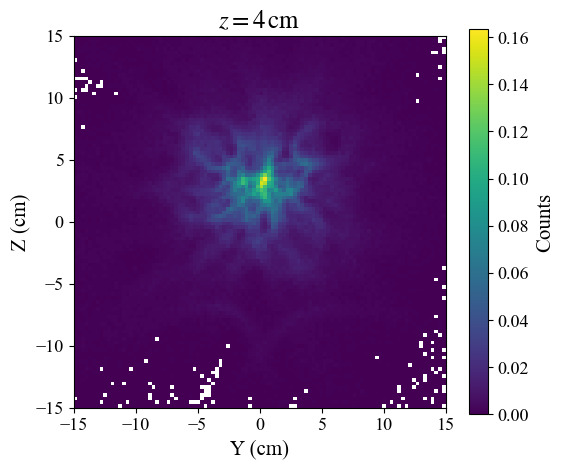

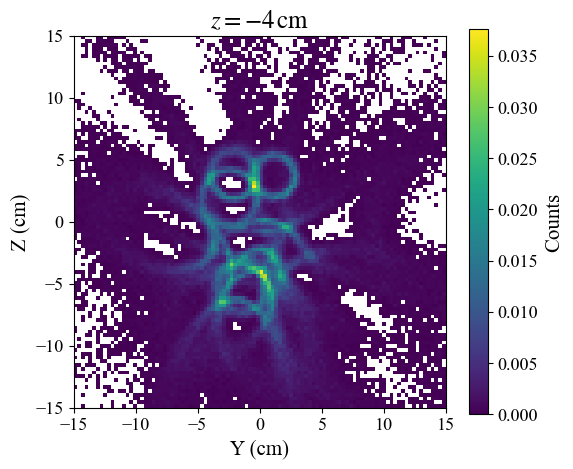

In [3]:
data_info_dict = {"z0cm": r"$z=0\,\mathrm{cm}$", "z4cm": r"$z=4\,\mathrm{cm}$", "zm4cm": r"$z=-4\,\mathrm{cm}$"}

for data_type, title in data_info_dict.items():
    filePath = f"../products/{data_type}/compton_image.root"
    plotBackProjection(filePath, num_points=10000, title=title)